In [19]:
import torch
from torch import nn, optim

## 转置卷积API

In [20]:
conv_T = nn.ConvTranspose2d(in_channels=3, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1)

In [21]:
# 定义输入
input = torch.randn(1, 3, 32, 32)

In [22]:
# 转置卷积
output = conv_T(input)
print(output.shape)

torch.Size([1, 16, 64, 64])


## 去噪自编码器案例

### 1. 准备数据

In [23]:
from PIL import Image # 加载图像处理库
import torchvision.transforms as T # 图像转换
import matplotlib.pyplot as plt

In [24]:
# 1. 加载原始图片
image = Image.open('Apple.jpg')
print(image)

<PIL.WebPImagePlugin.WebPImageFile image mode=RGB size=600x574 at 0x144513250>


In [25]:
# 定义图像转换操作*（调整大小，转为Tensor）
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
])
# 2. 转换图片
img_tensor = transform(image)
print(img_tensor.shape)

torch.Size([3, 256, 256])


In [26]:
# 3. 转换为ndarray，方便画图
img_numpy = img_tensor.permute(1, 2, 0).numpy() # permute(1, 2, 0) 是为了将通道维度放到最后，符合matplotlib的要求
print(img_numpy.shape)

(256, 256, 3)


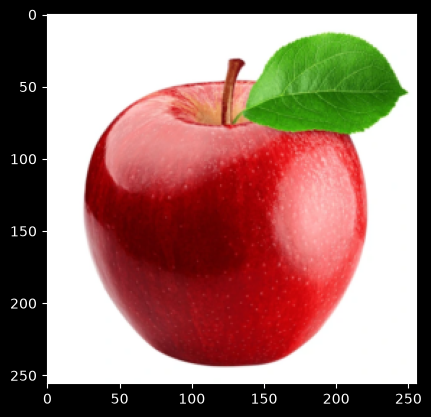

In [27]:
#  画图
plt.imshow(img_numpy)
plt.show()

In [28]:
# 4. 加入噪声，得到模型的输入
img_noise = img_tensor + torch.randn_like(img_tensor) * 0.2

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7981854..1.8271428].


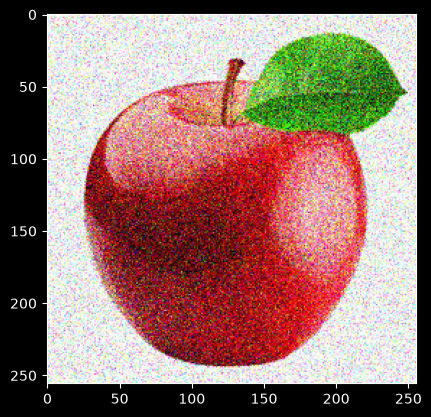

In [29]:
# 5. 将噪声图片转换为ndarray, 画图
img_noise_numpy = img_noise.permute(1, 2, 0).numpy()
plt.imshow(img_noise_numpy)
plt.show()

### 2. 定义模型

In [30]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # 编码器
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1), # 输出的特征形状不变
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # 输出的形状为输入的一半

            nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        )
        # 解码器
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=8, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1), # 输出的形状为输入的两倍
            nn.ReLU(),

            nn.ConvTranspose2d(in_channels=16, out_channels=3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # 编码
        features = self.encoder(x)
        # print("编码输出特征形状，", features.shape)
        # 解码
        output = self.decoder(features)
        # print("解码输出图像形状", output.shape)
        return output

In [31]:
model = Autoencoder()
# 测试前向传播
input = torch.randn(10, 3, 256, 256)
output = model(input)

### 3. 模型训练

In [32]:
# 1. 定义设备
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)

In [33]:
# 2. 定义超参数
lr = 0.001
epochs = 500

In [34]:
# 3. 定义损失函数和优化器
loss_fn = nn.MSELoss() # 均方误差损失函数
optimizer = optim.Adam(model.parameters(), lr=lr)

In [36]:
# 4. 训练
for epoch in range(epochs):
    # 将输入和目标数据放到设备上
    input = img_noise.to(device)
    target = img_tensor.to(device)

    # 前向传播，得出输出
    output = model(input)
    # 计算损失
    loss = loss_fn(output, target)
    # 反向传播， 计算梯度
    loss.backward()
    # 更新参数
    optimizer.step()
    # 梯度清零
    optimizer.zero_grad()

    # 每50轮打印一次损失
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [50/500], Loss: 0.0029
Epoch [100/500], Loss: 0.0027
Epoch [150/500], Loss: 0.0026
Epoch [200/500], Loss: 0.0024
Epoch [250/500], Loss: 0.0023
Epoch [300/500], Loss: 0.0023
Epoch [350/500], Loss: 0.0022
Epoch [400/500], Loss: 0.0021
Epoch [450/500], Loss: 0.0021
Epoch [500/500], Loss: 0.0020


In [37]:
# 5. 保存模型
torch.save(model.state_dict(), 'model.pt')

### 4. 模型推理

In [38]:
with torch.no_grad():
    input = img_noise.to(device)
    # 前向传播，得到重构图像
    output = model(input)

In [39]:
print(output.shape)

torch.Size([3, 256, 256])


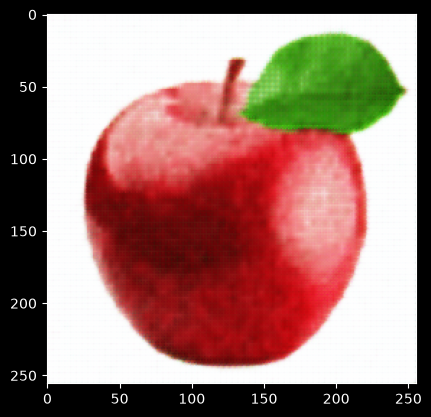

In [42]:
# 将输出图像转换为ndarray，画图
output_numpy = output.cpu().permute(1, 2, 0).numpy()
plt.imshow(output_numpy)
plt.show()